One-hot encoding
Dummy coding
effect coding

database Iris

1. One-Hot Encoding

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder

In [25]:
iris=load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [46]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df["target"]=iris.target
print(df.iloc[[49,99,149]].T)

                   49   99   149
sepal length (cm)  5.0  5.7  5.9
sepal width (cm)   3.3  2.8  3.0
petal length (cm)  1.4  4.1  5.1
petal width (cm)   0.2  1.3  1.8
target             0.0  1.0  2.0


In [47]:
df['target'] = df['target'].map({ 0: 'setosa', 1: 'versicolor', 2: 'virginica'})
print(df.iloc[[49, 99, 149]].T)

                      49          99         149
sepal length (cm)     5.0         5.7        5.9
sepal width (cm)      3.3         2.8        3.0
petal length (cm)     1.4         4.1        5.1
petal width (cm)      0.2         1.3        1.8
target             setosa  versicolor  virginica


In [52]:
encoder = OneHotEncoder(sparse_output=False)
encoded_ohe = encoder.fit_transform(df[['target']])
ohe_cols = encoder.get_feature_names_out(['target'])

df_ohe = pd.concat([df, pd.DataFrame(encoded_ohe, columns=ohe_cols)], axis=1)
print(df_ohe.iloc[[49, 99, 149]].T)

                      49          99         149
sepal length (cm)     5.0         5.7        5.9
sepal width (cm)      3.3         2.8        3.0
petal length (cm)     1.4         4.1        5.1
petal width (cm)      0.2         1.3        1.8
target             setosa  versicolor  virginica
target_setosa         1.0         0.0        0.0
target_versicolor     0.0         1.0        0.0
target_virginica      0.0         0.0        1.0


2. Dummy Coding

In [53]:
encoded_dummy=pd.get_dummies(df["target"],drop_first=True,dtype=int)
df_dummy=pd.concat([df,encoded_dummy],axis=1)

print(df_dummy.iloc[[49,99,149]].T)

                      49          99         149
sepal length (cm)     5.0         5.7        5.9
sepal width (cm)      3.3         2.8        3.0
petal length (cm)     1.4         4.1        5.1
petal width (cm)      0.2         1.3        1.8
target             setosa  versicolor  virginica
versicolor              0           1          0
virginica               0           0          1


3. Effect Coding

In [57]:
effect = pd.get_dummies(df['target'], dtype=int)
reference_col = 'setosa'
effect[reference_col] = effect[reference_col].replace(1, -1)
df_effect = pd.concat([df, effect], axis=1)

print(df_effect.iloc[[49,99,149]].T)

                      49          99         149
sepal length (cm)     5.0         5.7        5.9
sepal width (cm)      3.3         2.8        3.0
petal length (cm)     1.4         4.1        5.1
petal width (cm)      0.2         1.3        1.8
target             setosa  versicolor  virginica
setosa                 -1           0          0
versicolor              0           1          0
virginica               0           0          1


Visualizzazione Encoding

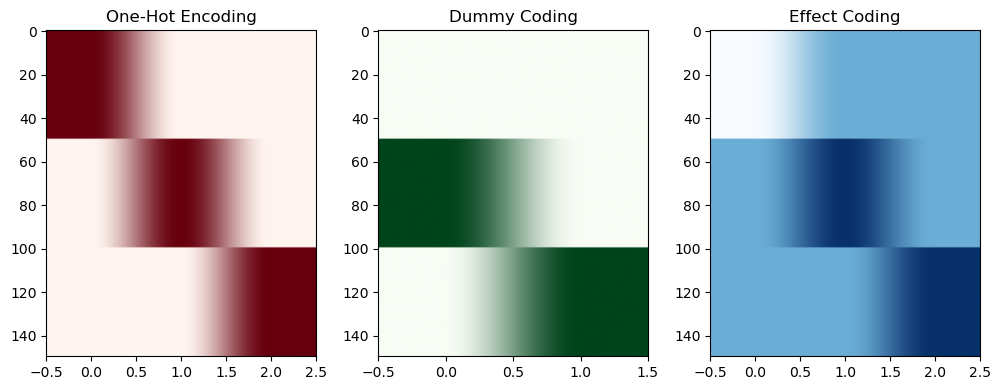

In [61]:
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(df_ohe[ohe_cols],cmap="Reds",aspect="auto")
plt.title("One-Hot Encoding")

plt.subplot(1,3,2)
plt.imshow(df_dummy[["versicolor","virginica"]],cmap="Greens",aspect="auto")
plt.title("Dummy Coding")

plt.subplot(1,3,3)
plt.imshow(df_effect[["setosa","versicolor","virginica"]],cmap="Blues",aspect="auto")
plt.title("Effect Coding")

plt.tight_layout()
plt.show()